In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


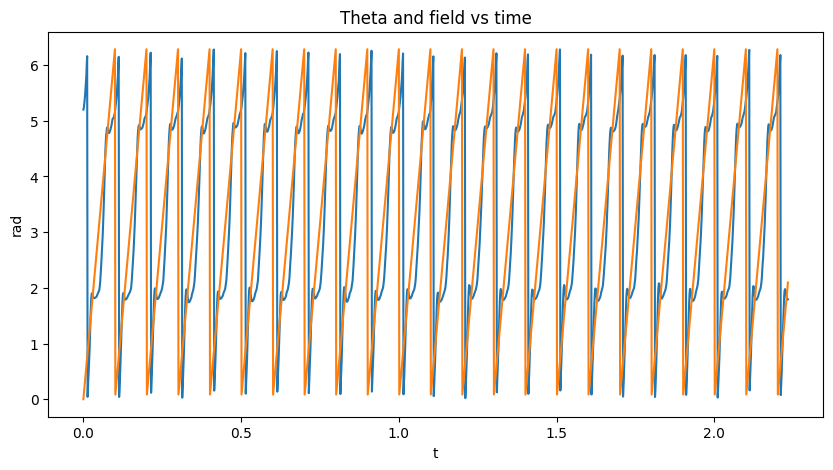

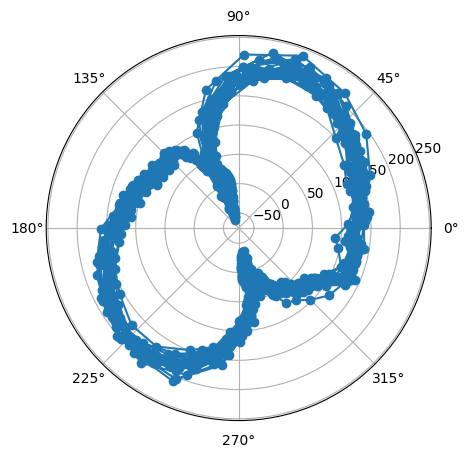

In [20]:
filenames = ["locomotion/d10hz1-1.csv", "locomotion/d10hz2-2.csv"]
dfs = [pd.read_csv(filename, header=1) for filename in filenames]
for df in dfs:
    df.columns = ['time', 'x', 'y', 'theta', 'omega', 'alpha']

w_field = 10 # Hz 
w_field = 2 * np.pi * w_field


dt = dfs[0]['time'].values[1] - dfs[0]['time'].values[0]
thetas = []
for df in dfs:
    thetas.extend(df['theta'].values)
thetas = np.array(thetas) * np.pi / 180

omegas = []
for df in dfs:
    omegas.extend(df['omega'].values)
omegas = np.array(omegas) * np.pi / 180
ts = np.arange(0, len(thetas))*dt
theta_field = w_field * ts


# plot of theta vs time
plt.figure(figsize=(10, 5))
thetas_wrapped = thetas % (2 * np.pi)
field_wrapped = theta_field % (2 * np.pi)
plt.plot(ts, thetas_wrapped)
plt.plot(ts, field_wrapped)
plt.title('Theta and field vs time')
plt.xlabel('t')
plt.ylabel('rad')
plt.show()

# polar plot of theta vs omega
plt.figure(figsize=(5, 5))
plt.polar(thetas, omegas, '-o')
plt.show()


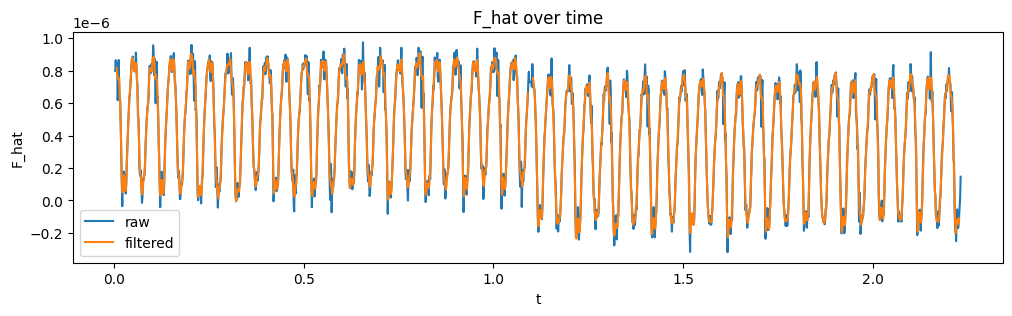

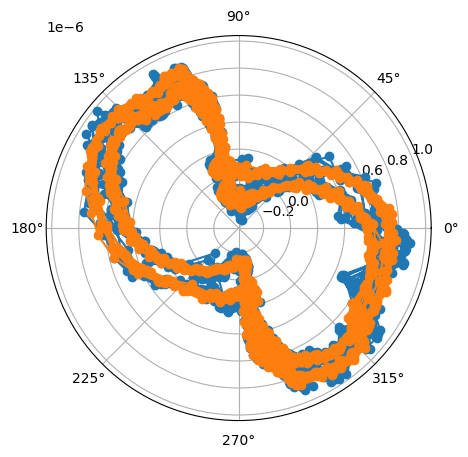

In [21]:
# Dynamics-related quantities and F_hat computation
m = 1.4e-5
d = 2e-3
J = 1/6 * m * d**2
B = 1e-6
wb = 10 * 2 * np.pi

# compute second derivative and estimated forcing
# note: ts, thetas, omegas were computed above
dt = ts[1] - ts[0]
# omega is theta_dot, so theta_dd ~ d omega / dt
# np.diff yields len-1, so align arrays accordingly
theta_dd = np.diff(omegas)/(dt)

F_hat = B*np.sin(theta_field[1:] - thetas[1:]) - J*theta_dd

from scipy.signal import savgol_filter

# Smooth F_hat if desired
F_hat_filtered = savgol_filter(F_hat, window_length=7, polyorder=3)

# Trim inputs to match F_hat length
theta = (thetas[1:] % (2*np.pi))
omega = omegas[1:]
f_hat = F_hat_filtered

plt.figure(figsize=(12, 3))
plt.plot(ts[1:], F_hat, label='raw')
plt.plot(ts[1:], F_hat_filtered, label='filtered')
plt.legend()
plt.title('F_hat over time')
plt.xlabel('t')
plt.ylabel('F_hat')
plt.show()

# polar plot of theta vs omega
plt.figure(figsize=(5, 5))
plt.polar(thetas[1:], F_hat, '-o')
plt.polar(thetas[1:], F_hat_filtered, '-o')
plt.show()


In [22]:
# Interactive 3D scatter plot
%pip install plotly -q
import plotly.express as px
import pandas as pd

# F_hat = f_hat

# Create a DataFrame for Plotly
df_plot = pd.DataFrame({
    'theta': theta,
    'omega': omega,
    'f_hat': F_hat
})

# Clean NaNs for plotting, just in case
df_plot_clean = df_plot.dropna()

fig = px.scatter_3d(
    df_plot_clean,
    x='theta',
    y='omega',
    z='f_hat',
    color='f_hat',
    color_continuous_scale='Viridis',
    opacity=0.7,
    title='Interactive 3D Scatter Plot of F_hat vs Theta and Omega',
)
fig.update_layout(scene=dict(
    xaxis_title='Theta (rad)',
    yaxis_title='Omega (rad/s)',
    zaxis_title='F_hat'
))


# Set the size to be a 700x700 square
fig.update_layout(
    width=700,
    height=700,
    scene=dict(
        xaxis_title='Theta (rad)',
        yaxis_title='Omega (rad/s)',
        zaxis_title='F_hat'
    )
)
# Set the marker size here (e.g., 2). You can change this value.
fig.update_traces(marker_size=2)

fig.show()


Note: you may need to restart the kernel to use updated packages.


In [5]:
# Interactive 3D Polar Representation Plot
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Re-use the clean DataFrame from the previous interactive plot cell
# If that cell wasn't run, create and clean the DataFrame here
if 'df_plot_clean' not in locals():
    df_plot = pd.DataFrame({'theta': theta, 'omega': omega, 'f_hat': f_hat})
    df_plot_clean = df_plot.dropna()

# --- Create the correct polar projection ---
# Here, we map (theta, omega) to a polar layout on the X-Y plane.
# omega -> radius (r)
# theta -> angle (phi)
r = df_plot_clean['omega']
phi = df_plot_clean['theta']

# Convert polar coordinates to Cartesian for plotting
x_new = r * np.cos(phi)
y_new = r * np.sin(phi)
z_new = df_plot_clean['f_hat']

# Create the figure
fig = go.Figure(data=[go.Scatter3d(
    x=x_new,
    y=y_new,
    z=z_new,
    mode='markers',
    marker=dict(
        size=3,
        color=z_new,                # set color to the z-axis value (f_hat)
        colorscale='Viridis',       # choose a colorscale
        colorbar=dict(title='F_hat'),
        opacity=0.8
    )
)])

# Update the layout for a clean, square plot
fig.update_layout(
    title='3D Polar Representation: F_hat vs (omega, theta)',
    width=800,
    height=800,
    scene=dict(
        xaxis_title='X  (omega * cos(theta))',
        yaxis_title='Y  (omega * sin(theta))',
        zaxis_title='Z  (F_hat)'
    ),
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()


In [23]:
# Prepare dataset for fitting
X = np.column_stack([theta, omega])
y = F_hat

# Clean NaNs
valid_mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
X_clean = X[valid_mask]
y_clean = y[valid_mask]
ts_clean = ts[1:][valid_mask]

print(f"Shapes: X_clean={X_clean.shape}, y_clean={y_clean.shape}")

Shapes: X_clean=(1670, 2), y_clean=(1670,)


In [8]:
X_sined = np.column_stack([np.sin(X_clean[:, 0]), np.cos(X_clean[:, 0]), X_clean[:, 1]])
X_sined

array([[ -0.66171422,   0.74975616,  81.13142084],
       [ -0.57837543,   0.81577072,  91.10323735],
       [ -0.46192184,   0.88692064, 127.89882714],
       ...,
       [  0.92524945,  -0.37935927, -23.0482596 ],
       [  0.94145878,  -0.33712812, -35.6887718 ],
       [  0.95710737,  -0.28973347, -36.95593319]], shape=(1658, 3))

In [33]:
# Polynomial-only modeling
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Configure polynomial model (degree can be tuned)
for degree in [3,4,5,6,7,8,9,10]:
    # degree = 5
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1e-5)),
    ])

    poly_model.fit(X_clean, y_clean)
    # poly_model.fit(X_sined, y_clean)
    y_pred = poly_model.predict(X_clean)
    # y_pred = poly_model.predict(X_sined)
    r2 = r2_score(y_clean, y_pred)
    print(f"Polynomial (deg={degree}) R²: {r2:.4f}")

    # Extract feature names and coefficients
    poly = poly_model.named_steps['poly']
    scaler = poly_model.named_steps['scaler']
    ridge = poly_model.named_steps['ridge']

    feature_names = poly.get_feature_names_out(['theta', 'omega'])
    coef = ridge.coef_
    intercept = ridge.intercept_

    # Pretty-print top terms
    pairs = sorted([(abs(c), c, n) for c, n in zip(coef, feature_names)], reverse=True)
    # print("Top terms:")
    # for _, c, n in pairs[:]:
    #     print(f"  {c:12.2e} * {n}")

    # --- Correct Manual Prediction ---
    # 1. Create polynomial features
    X_poly = poly.transform(X_clean)
    # X_poly = poly.transform(X_sined)
    # 2. Scale the polynomial features using the fitted scaler
    X_poly_scaled = scaler.transform(X_poly)
    # 3. Apply coefficients and add the intercept
    y_pred_manual = X_poly_scaled @ coef + intercept

    # Check if y_pred_manual is close to y_pred (obtained above)
    diff = np.abs(y_pred_manual - y_pred)
    # print(f"\nMax absolute difference between manual and model prediction: {np.max(diff):.3e}")
    # print(f"All close: {np.allclose(y_pred_manual, y_pred)}")




Polynomial (deg=3) R²: 0.5132
Polynomial (deg=4) R²: 0.6377
Polynomial (deg=5) R²: 0.6807
Polynomial (deg=6) R²: 0.7526
Polynomial (deg=7) R²: 0.7655
Polynomial (deg=8) R²: 0.7767
Polynomial (deg=9) R²: 0.7844
Polynomial (deg=10) R²: 0.7889


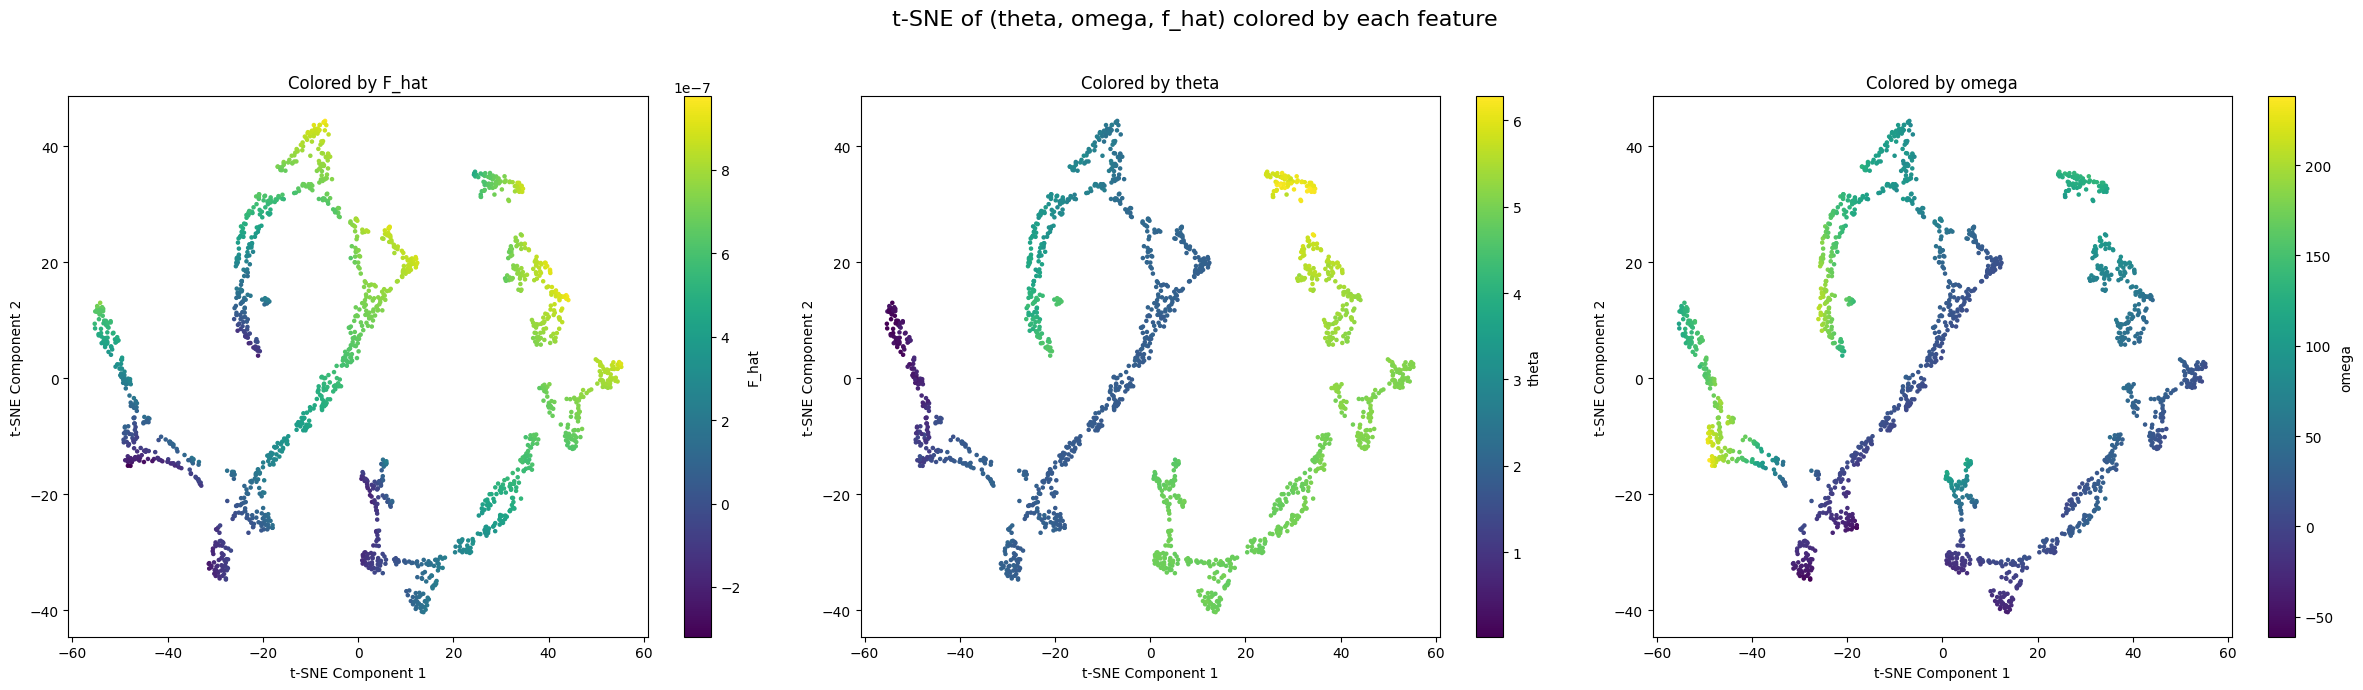

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for plotting using x_clean
df_plot = pd.DataFrame({
    'theta': X_clean[:, 0],
    'omega': X_clean[:, 1],
    'f_hat': y_clean
})

# Scale the data before applying t-SNE
scaler = StandardScaler()
df_plot_scaled = scaler.fit_transform(df_plot)

# Apply t-SNE to the scaled data
# You can experiment with perplexity, typical values are between 5 and 50
tsne = TSNE(n_components=2, random_state=42, perplexity=30) 
df_tsne = tsne.fit_transform(df_plot_scaled)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('t-SNE of (theta, omega, f_hat) colored by each feature', fontsize=16)

# Plot t-SNE colored by F_hat
sc1 = axes[0].scatter(df_tsne[:, 0], df_tsne[:, 1], c=df_plot['f_hat'], cmap='viridis', s=5)
fig.colorbar(sc1, ax=axes[0]).set_label('F_hat')
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')
axes[0].set_title('Colored by F_hat')

# Plot t-SNE colored by theta
sc2 = axes[1].scatter(df_tsne[:, 0], df_tsne[:, 1], c=df_plot['theta'], cmap='viridis', s=5)
fig.colorbar(sc2, ax=axes[1]).set_label('theta')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].set_title('Colored by theta')

# Plot t-SNE colored by omega
sc3 = axes[2].scatter(df_tsne[:, 0], df_tsne[:, 1], c=df_plot['omega'], cmap='viridis', s=5)
fig.colorbar(sc3, ax=axes[2]).set_label('omega')
axes[2].set_xlabel('t-SNE Component 1')
axes[2].set_ylabel('t-SNE Component 2')
axes[2].set_title('Colored by omega')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Shape of our input feature matrix X: (1670, 2)
Shape of our output array F: (1670,)
Running t-SNE... (this may take a moment)
Shape of t-SNE results: (1670, 2)

Plot saved as 'tsne_visualization.png'


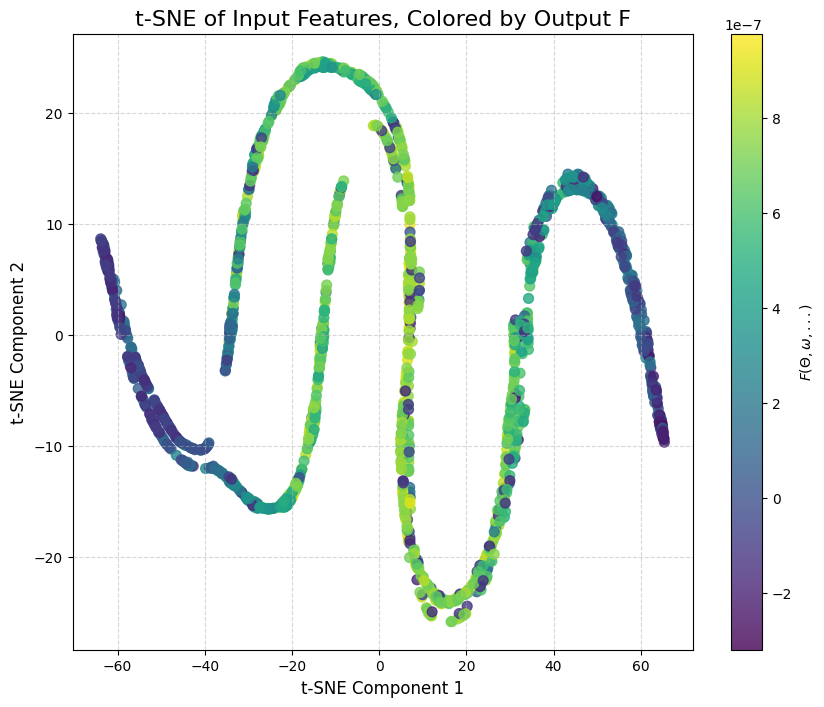

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# --- 1. Create Simulated Data ---
# Imagine you have nwo samples and D features.
nwo = 500  # Number of samples
n_features = 10    # Total number of input features

# Create a (nwo x n_features) matrix for the input features
# This 'X' matrix represents all your input data.
X = X_clean

# Let's define F as a function of the first two features (our "theta" and "omega")
# to create a clear structure for the plot to find.
# We'll call X[:, 0] 'theta' and X[:, 1] 'omega' for this example.
theta = X_clean[:, 0]
omega = X_clean[:, 1]

# F is a non-linear function of theta and omega
F = y_clean

print(f"Shape of our input feature matrix X: {X.shape}")
print(f"Shape of our output array F: {F.shape}")

# --- 2. Run t-SNE ---
# We run t-SNE on the *input features* X.
# Perplexity is a key parameter; 30-50 is a common starting point

# --- 2. Run t-SNE ---
print("Running t-SNE... (this may take a moment)")
tsne = TSNE(
    n_components=2,     # We want a 2D plot
    perplexity=40,      # A common value, related to the number of neighbors
    max_iter=1000,      # <-- This is the corrected line
    random_state=42     # For reproducible results
)

# This is the key step:
tsne_results = tsne.fit_transform(X)

print(f"Shape of t-SNE results: {tsne_results.shape}")

# --- 3. Plot the Results ---
# We create a scatter plot of the two t-SNE components.
# We *color* the points using our output function F.

plt.figure(figsize=(10, 8))

# The scatter plot
# x = the first t-SNE component
# y = the second t-SNE component
# c = the array to use for coloring (our function F)
# cmap = a colormap



sc = plt.scatter(
    tsne_results[:, 0],
    tsne_results[:, 1],
    c=y_clean,
    cmap='viridis',  # 'viridis', 'coolwarm', or 'plasma' are good choices
    alpha=0.8,
    s=50
)

# Add a colorbar to show the mapping of F values to colors
plt.colorbar(sc, label='$F(\Theta, \omega, ...)$')

# Add labels and title
plt.title('t-SNE of Input Features, Colored by Output F', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Save the figure
plt.savefig('tsne_visualization.png', dpi=300, bbox_inches='tight')

print("\nPlot saved as 'tsne_visualization.png'")

In [9]:
# Polynomial-only modeling
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Configure polynomial model (degree can be tuned)
for degree in [3,4,5,6,7,8,9,10]:
    # degree = 5
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1e-5)),
    ])

    # poly_model.fit(X_clean, y_clean)
    poly_model.fit(X_sined, y_clean)
    # y_pred = poly_model.predict(X_clean)
    y_pred = poly_model.predict(X_sined)
    r2 = r2_score(y_clean, y_pred)
    print(f"Polynomial (deg={degree}) R²: {r2:.4f}")

    # Extract feature names and coefficients
    poly = poly_model.named_steps['poly']
    scaler = poly_model.named_steps['scaler']
    ridge = poly_model.named_steps['ridge']

    feature_names = poly.get_feature_names_out(['sin(theta)', 'cos(theta)', 'omega'])
    coef = ridge.coef_
    intercept = ridge.intercept_

    # Pretty-print top terms
    pairs = sorted([(abs(c), c, n) for c, n in zip(coef, feature_names)], reverse=True)
    # print("Top terms:")
    # for _, c, n in pairs[:]:
    #     print(f"  {c:12.2e} * {n}")

    # --- Correct Manual Prediction ---
    # 1. Create polynomial features
    # X_poly = poly.transform(X_clean)
    X_poly = poly.transform(X_sined)
    # 2. Scale the polynomial features using the fitted scaler
    X_poly_scaled = scaler.transform(X_poly)
    # 3. Apply coefficients and add the intercept
    y_pred_manual = X_poly_scaled @ coef + intercept

    # Check if y_pred_manual is close to y_pred (obtained above)
    diff = np.abs(y_pred_manual - y_pred)
    # print(f"\nMax absolute difference between manual and model prediction: {np.max(diff):.3e}")
    # print(f"All close: {np.allclose(y_pred_manual, y_pred)}")




Polynomial (deg=3) R²: 0.7032
Polynomial (deg=4) R²: 0.7171
Polynomial (deg=5) R²: 0.7653
Polynomial (deg=6) R²: 0.7942
Polynomial (deg=7) R²: 0.8119
Polynomial (deg=8) R²: 0.8190
Polynomial (deg=9) R²: 0.8230
Polynomial (deg=10) R²: 0.8272


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Based on the t-SNE plots, f_hat seems to be primarily a function of omega.
# Let's verify this by plotting them directly against each other.

omega = X_clean[:, 1]
f_hat = y_clean

# To visualize the trend clearly, we can fit a simple model.
# A polynomial is a good start for function approximation.
# Let's try a 3rd-degree polynomial. You can experiment with the degree.
degree = 3
coeffs = np.polyfit(omega, f_hat, degree)
poly_model = np.poly1d(coeffs)

# Generate points for the model's curve
omega_fit = np.linspace(omega.min(), omega.max(), 500)
f_hat_fit = poly_model(omega_fit)

# Calculate the R-squared score to quantify the model's performance
f_hat_pred_for_r2 = poly_model(omega)
r2 = r2_score(f_hat, f_hat_pred_for_r2)

# Create the plot
plt.figure(figsize=(12, 8))
# Plot the raw data points with some transparency
plt.scatter(omega, f_hat, alpha=0.2, s=15, label='Actual Data')
# Plot the polynomial fit
plt.plot(omega_fit, f_hat_fit, color='red', linewidth=3, label=f'Polynomial Fit (degree={degree})')
plt.title(f'Function Approximation: F_hat as a function of Omega (R-squared: {r2:.4f})', fontsize=16)
plt.xlabel('Omega (Angular Velocity)', fontsize=12)
plt.ylabel('F_hat (Estimated Function)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

print(f"Learned Polynomial Model: f(omega) = {coeffs[0]:.4f}*omega^3 + {coeffs[1]:.4f}*omega^2 + {coeffs[2]:.4f}*omega + {coeffs[3]:.4f}")



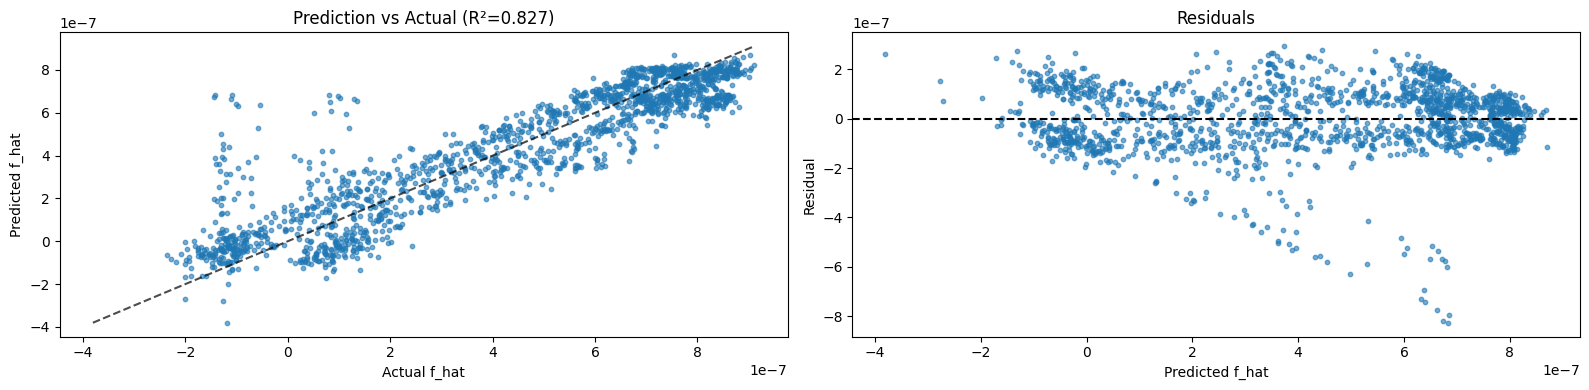

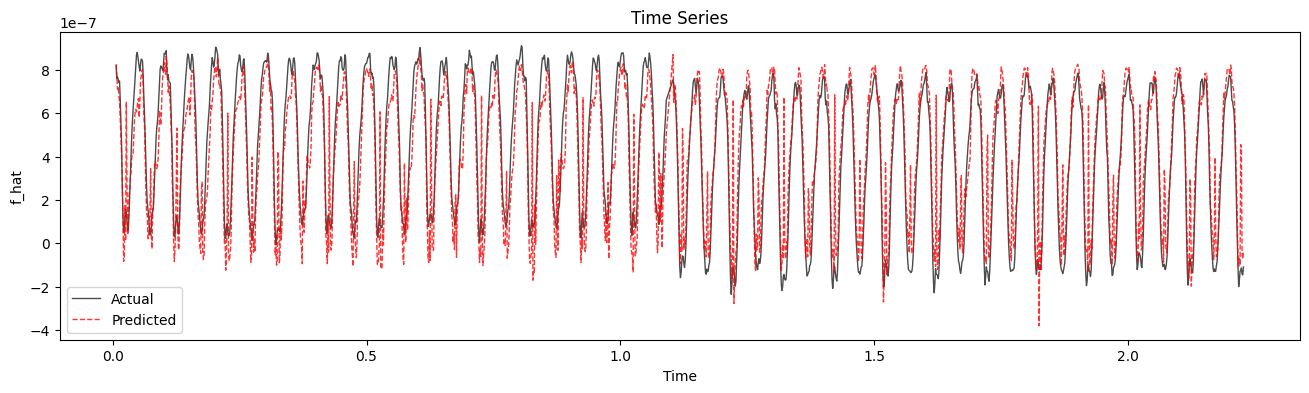

In [10]:
# Plots: prediction vs actual, time series, residuals
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_clean, y_pred, s=10, alpha=0.6)
lims = [min(y_clean.min(), y_pred.min()), max(y_clean.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', alpha=0.7)
plt.xlabel('Actual f_hat')
plt.ylabel('Predicted f_hat')
plt.title(f'Prediction vs Actual (R²={r2:.3f})')

plt.subplot(1, 2, 2)
res = y_clean - y_pred
plt.scatter(y_pred, res, s=10, alpha=0.6)
plt.axhline(0, color='k', ls='--')
plt.xlabel('Predicted f_hat')
plt.ylabel('Residual')
plt.title('Residuals')

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
plt.subplot(1, 1, 1)
plt.plot(ts_clean, y_clean, 'k-', lw=1, alpha=0.7, label='Actual')
plt.plot(ts_clean, y_pred, 'r--', lw=1, alpha=0.8, label='Predicted')
plt.xlabel('Time')
plt.ylabel('f_hat')
plt.title('Time Series')
plt.legend()

In [11]:
# Interactive 3D Polar Representation Plot
import plotly.graph_objects as go
import pandas as pd
import numpy as np


# --- Create the correct polar projection ---
# Here, we map (theta, omega) to a polar layout on the X-Y plane.
# omega -> radius (r)
# theta -> angle (phi)
r = X_clean[:, 1]
phi = X_clean[:, 0]

# Convert polar coordinates to Cartesian for plotting
x_new = r * np.cos(phi)
y_new = r * np.sin(phi)
z_new = y_pred

# Create the figure
fig = go.Figure(data=[go.Scatter3d(
    x=x_new,
    y=y_new,
    z=z_new,
    mode='markers',
    marker=dict(
        size=3,
        color=z_new,                # set color to the z-axis value (f_hat)
        colorscale='Viridis',       # choose a colorscale
        colorbar=dict(title='F_hat'),
        opacity=0.8
    )
)])

# Update the layout for a clean, square plot
fig.update_layout(
    title='3D Polar Representation: F_hat vs (omega, theta)',
    width=800,
    height=800,
    scene=dict(
        xaxis_title='X  (omega * cos(theta))',
        yaxis_title='Y  (omega * sin(theta))',
        zaxis_title='Z  (F_hat)'
    ),
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()


In [12]:
# Interactive 3D Polar Representation Plot
import plotly.graph_objects as go
import pandas as pd
import numpy as np


# --- Create the correct polar projection ---
# Here, we map (theta, omega) to a polar layout on the X-Y plane.
# omega -> radius (r)
# theta -> angle (phi)
r = X_clean[:, 1]
phi = X_clean[:, 0]

# Convert polar coordinates to Cartesian for plotting
x_new = r * np.cos(phi)
y_new = r * np.sin(phi)
z_new = y_pred

# Create the figure
fig = go.Figure(data=[go.Scatter3d(
    x=x_new,
    y=y_new,
    z=z_new,
    mode='markers',
    marker=dict(
        size=3,
        color=z_new,                # set color to the z-axis value (f_hat)
        colorscale='Viridis',       # choose a colorscale
        colorbar=dict(title='F_hat'),
        opacity=0.8
    )
)])

# Update the layout for a clean, square plot
fig.update_layout(
    title='3D Polar Representation: F_hat vs (omega, theta)',
    width=800,
    height=800,
    scene=dict(
        xaxis_title='X  (omega * cos(theta))',
        yaxis_title='Y  (omega * sin(theta))',
        zaxis_title='Z  (F_hat)'
    ),
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()


--- Preparing Data for MLP ---
Scaled X range: [-1.86, 2.61]
Scaled y range: [-1.99, 1.46]

--- Starting MLP Training ---
Epoch [400/5000], Train Loss: 1.4560e-01, Val Loss: 1.6041e-01
Epoch [800/5000], Train Loss: 1.2911e-01, Val Loss: 1.5262e-01
Epoch [1200/5000], Train Loss: 1.2291e-01, Val Loss: 1.5181e-01
Epoch [1600/5000], Train Loss: 1.1894e-01, Val Loss: 1.5064e-01
Epoch [2000/5000], Train Loss: 1.1587e-01, Val Loss: 1.5013e-01
Epoch [2400/5000], Train Loss: 1.1356e-01, Val Loss: 1.5026e-01
Epoch [2800/5000], Train Loss: 1.1148e-01, Val Loss: 1.4949e-01
Epoch [3200/5000], Train Loss: 1.0991e-01, Val Loss: 1.4976e-01
Epoch [3600/5000], Train Loss: 1.0873e-01, Val Loss: 1.4996e-01
Epoch [4000/5000], Train Loss: 1.0796e-01, Val Loss: 1.5014e-01
Epoch [4400/5000], Train Loss: 1.0757e-01, Val Loss: 1.5024e-01
Epoch [4800/5000], Train Loss: 1.0745e-01, Val Loss: 1.5026e-01

--- Evaluating Final Model ---

MLP (Corrected w/ Target Scaling) Final R²: 0.8840
Polynomial R² for comparison

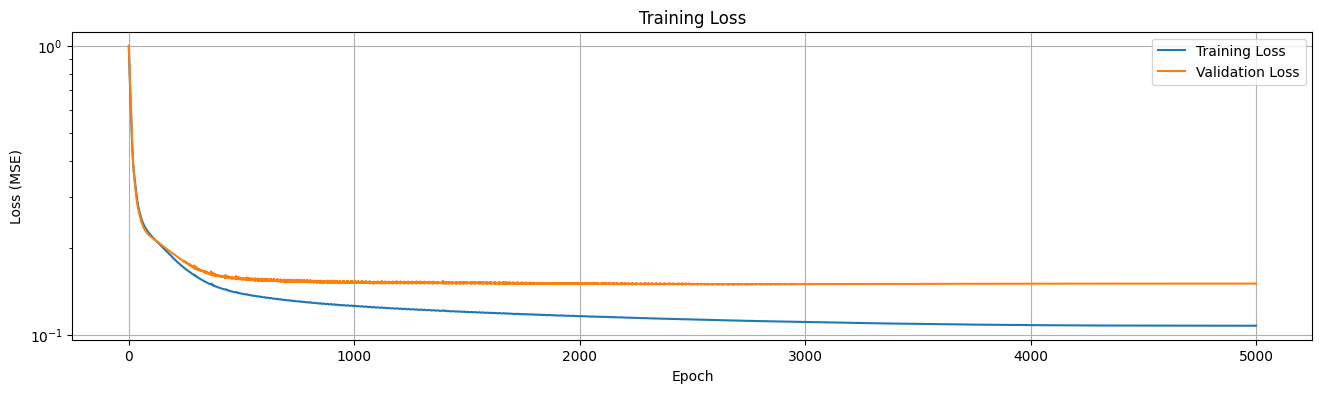

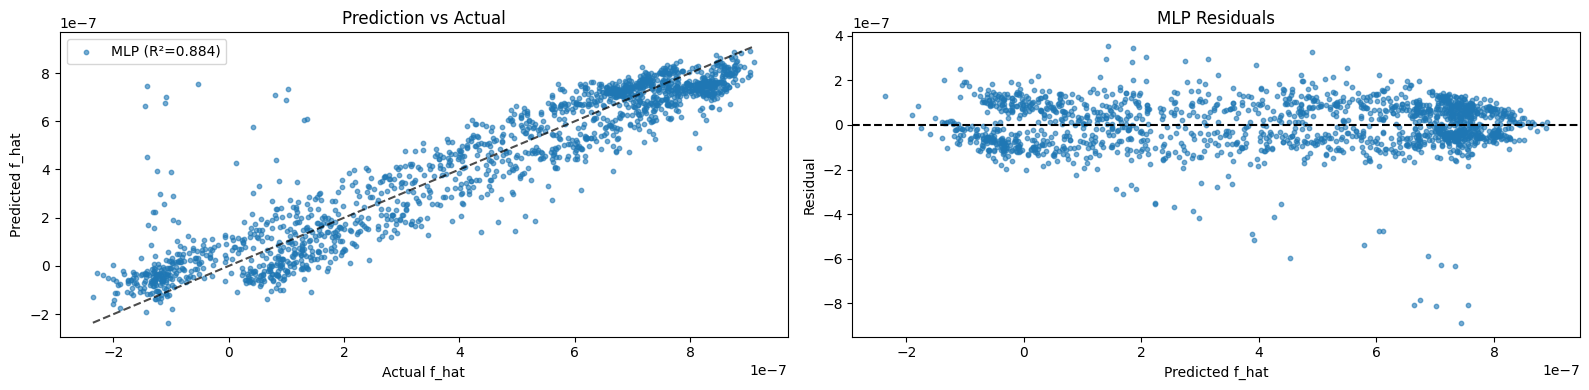

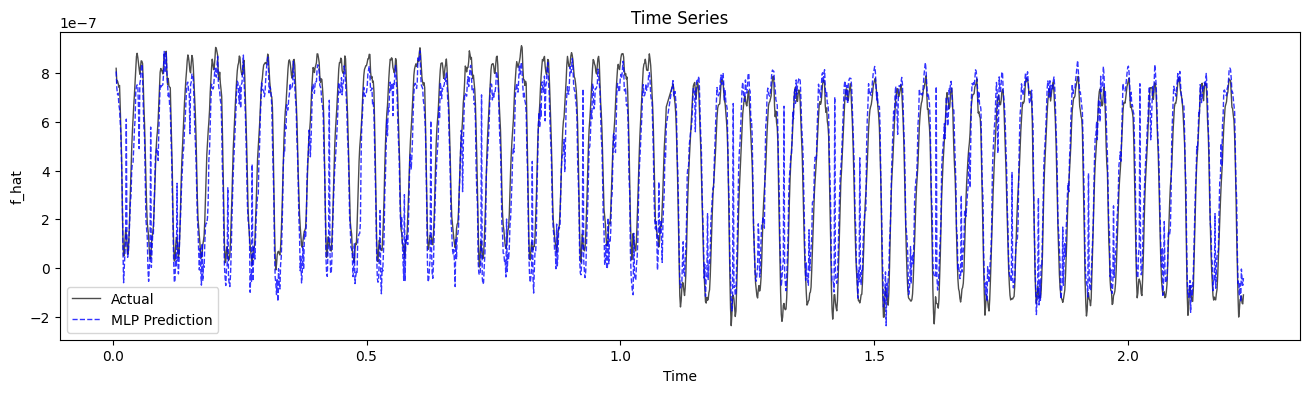

In [13]:
# --- 2-Layer MLP with PyTorch (Corrected with Target Scaling) ---
# The previous attempt failed catastrophically (R² ~ -15e6), which points to a
# major issue, not just poor tuning. The root cause is a mismatch between the
# network's output scale (~1) and the target y's scale (~1e-5).
# The correct approach is to scale BOTH the inputs and the targets.

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. Create Improved Input Features & Scale Inputs/Outputs
# Using [cos(theta), sin(theta), omega] is more expressive for periodic systems.
print("--- Preparing Data for MLP ---")
X_improved = np.column_stack([
    np.cos(X_clean[:, 0]),
    np.sin(X_clean[:, 0]),
    X_clean[:, 1]
])
y_reshaped = y_clean.reshape(-1, 1)

# Create separate scalers for inputs and outputs
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fit scalers on the full dataset (common practice before splitting for NN)
X_scaled = x_scaler.fit_transform(X_improved)
y_scaled = y_scaler.fit_transform(y_reshaped)

print(f"Scaled X range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"Scaled y range: [{y_scaled.min():.2f}, {y_scaled.max():.2f}]")


# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_improved, y_scaled, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

# 2. Define the MLP Architecture
class TwoLayerMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size1=256, hidden_size2=256, output_size=1, activation=nn.ReLU()):
        super(TwoLayerMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            activation,
            nn.Linear(hidden_size1, hidden_size2),
            activation,
            nn.Linear(hidden_size2, output_size)
        )
    def forward(self, x):
        return self.network(x)

# Hyperparameters
learning_rate = 5e-4
epochs = 5000

# Instantiate the model, loss, optimizer, and scheduler
mlp_model = TwoLayerMLP()
criterion = nn.MSELoss()
optimizer = optim.AdamW(mlp_model.parameters(), lr=learning_rate)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)
# cawr scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 3. Train the Model
print("\n--- Starting MLP Training ---")
train_losses, val_losses = [], []
for epoch in range(epochs):
    mlp_model.train()
    outputs = mlp_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    mlp_model.eval()
    with torch.no_grad():
        val_outputs = mlp_model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_losses.append(val_loss.item())
    
    scheduler.step()
    if (epoch + 1) % 400 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4e}, Val Loss: {val_loss.item():.4e}')

# 4. Evaluate and Plot Results
print("\n--- Evaluating Final Model ---")
mlp_model.eval()
with torch.no_grad():
    # Predict on the full (scaled) dataset
    X_full_t = torch.tensor(X_scaled, dtype=torch.float32)
    y_pred_scaled_t = mlp_model(X_full_t)
    
    # CRUCIAL STEP: Inverse transform the predictions to get back to the original scale
    y_pred_mlp = y_scaler.inverse_transform(y_pred_scaled_t.numpy()).flatten()

r2_mlp = r2_score(y_clean, y_pred_mlp)

print(f"\nMLP (Corrected w/ Target Scaling) Final R²: {r2_mlp:.4f}")
# Find the polynomial R^2 if it was calculated in a previous cell
try:
    poly_r2 = r2_score(y_clean, y_pred)
    print(f"Polynomial R² for comparison: {poly_r2:.4f}")
except NameError:
    print("Polynomial R² not available for comparison.")


# Plotting
plt.figure(figsize=(16, 4))
# Plot 1: Training Loss
plt.subplot(1, 1, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)'); plt.title('Training Loss')
plt.yscale('log'); plt.legend(); plt.grid(True)

plt.figure(figsize=(16, 4))

# Plot 2: Prediction vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_clean, y_pred_mlp, s=10, alpha=0.6, label=f'MLP (R²={r2_mlp:.3f})')
lims = [min(y_clean.min(), y_pred_mlp.min()), max(y_clean.max(), y_pred_mlp.max())]
plt.plot(lims, lims, 'k--', alpha=0.7)
plt.xlabel('Actual f_hat'); plt.ylabel('Predicted f_hat'); plt.title('Prediction vs Actual')
plt.legend()

# Plot 4: Residuals
plt.subplot(1, 2, 2)
res_mlp = y_clean - y_pred_mlp
plt.scatter(y_pred_mlp, res_mlp, s=10, alpha=0.6)
plt.axhline(0, color='k', ls='--')
plt.xlabel('Predicted f_hat'); plt.ylabel('Residual'); plt.title('MLP Residuals')

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
# Plot 3: Time Series
plt.subplot(1, 1, 1)
plt.plot(ts_clean, y_clean, 'k-', lw=1, alpha=0.7, label='Actual')
plt.plot(ts_clean, y_pred_mlp, 'b--', lw=1, alpha=0.8, label='MLP Prediction')
plt.xlabel('Time'); plt.ylabel('f_hat'); plt.title('Time Series'); plt.legend()

In [14]:
# Interactive 3D Polar Representation Plot
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# --- Create the correct polar projection ---
# Here, we map (theta, omega) to a polar layout on the X-Y plane.
# omega -> radius (r)
# theta -> angle (phi)
r = X_clean[:, 1]

# Convert polar coordinates to Cartesian for plotting
x_new = r * X_improved[:, 0]
y_new = r * X_improved[:, 1]
z_new = y_pred_mlp

# Create the figure
fig = go.Figure(data=[go.Scatter3d(
    x=x_new,
    y=y_new,
    z=z_new,
    mode='markers',
    marker=dict(
        size=3,
        color=z_new,                # set color to the z-axis value (f_hat)
        colorscale='Viridis',       # choose a colorscale
        colorbar=dict(title='F_hat'),
        opacity=0.8
    )
)])

# Update the layout for a clean, square plot
fig.update_layout(
    title='3D Polar Representation: F_hat vs (omega, theta)',
    width=800,
    height=800,
    scene=dict(
        xaxis_title='X  (omega * cos(theta))',
        yaxis_title='Y  (omega * sin(theta))',
        zaxis_title='Z  (F_hat)'
    ),
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()



Text(0.5, 1.0, 't-SNE of (theta, omega, f_hat)')

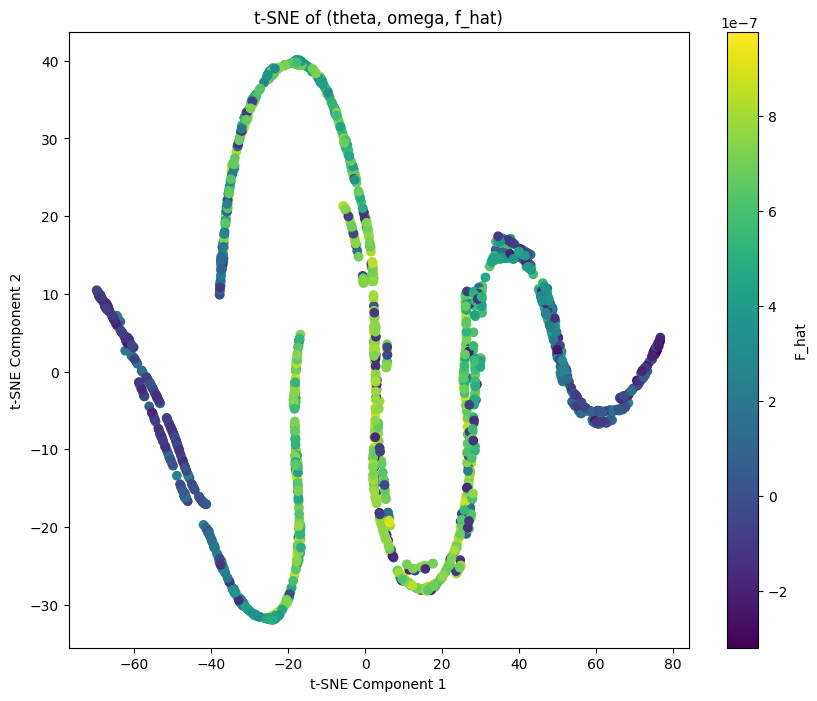

In [24]:
# try getting a tsne plot of just theta, omega and f_hat
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE



# Create a DataFrame for plotting using x_clean
df_plot = pd.DataFrame({
    'theta': X_clean[:, 0],
    'omega': X_clean[:, 1],
    'f_hat': y_clean
})

# Apply t-SNE to the data
tsne = TSNE(n_components=2, random_state=42)
df_tsne = tsne.fit_transform(df_plot[['theta', 'omega', 'f_hat']])

# Create a scatter plot of the t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(df_tsne[:, 0], df_tsne[:, 1], c=df_plot['f_hat'], cmap='viridis')
plt.colorbar(label='F_hat')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of (theta, omega, f_hat)')


Text(0.5, 0.92, 't-SNE of (sin(theta), cos(theta), omega, f_hat)')

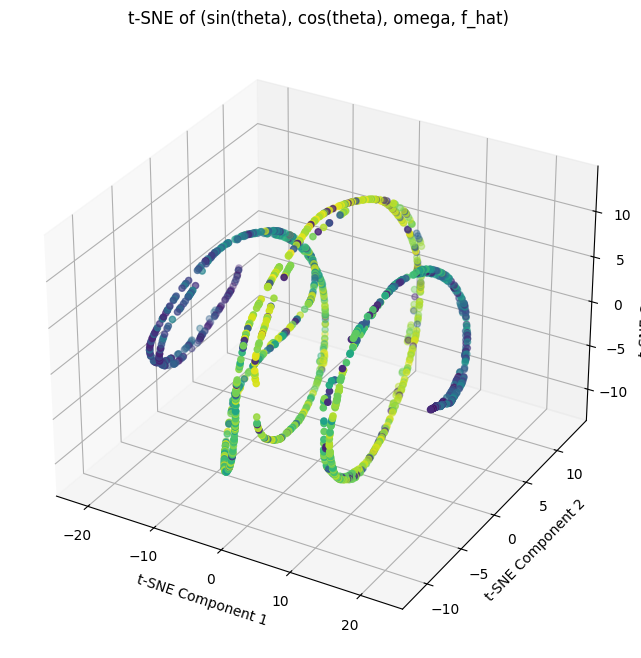

In [ ]:
# try getting a tsne plot of sin theta, cos theta, omega and f_hat
df_plot = pd.DataFrame({
    'sin_theta': np.sin(X_clean[:, 0]),
    'cos_theta': np.cos(X_clean[:, 0]),
    'omega': X_clean[:, 1],
    'f_hat': y_clean
})

# Apply t-SNE to the data, 3 components
tsne = TSNE(n_components=3, random_state=42)
df_tsne = tsne.fit_transform(df_plot[['sin_theta', 'cos_theta', 'omega', 'f_hat']])

# Create a scatter plot of the t-SNE results
plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.scatter(df_tsne[:, 0], df_tsne[:, 1], df_tsne[:, 2], c=df_plot['f_hat'], cmap='viridis')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
plt.title('t-SNE of (sin(theta), cos(theta), omega, f_hat)')